# Cellpose-SAM workbook
**Kernel:** `Cellpose-SAM Apple M1 (.venv)`.

Run setup once, list your files, choose an image, then edit/rerun the preview cell with **Ctrl+Enter**. The image and model remain in memory; rerun the image-loading cell only when choosing another image. This workbook segments 2D Z projections (max by default; mean or sum selectable) with optional median/Gaussian smoothing of the model input.

In [6]:
from pathlib import Path
import sys
from time import perf_counter
from importlib.metadata import version

import numpy as np
import tifffile
from scipy import ndimage
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm
from cellpose import models, plot

print(f"Cellpose {version('cellpose')} | PyTorch {torch.__version__}")
print(f"Kernel: {sys.executable}")
print("MPS built:", torch.backends.mps.is_built())
print("MPS available:", torch.backends.mps.is_available())
if not torch.backends.mps.is_available():
    raise RuntimeError("MPS unavailable: select the Cellpose-SAM Apple M1 (.venv) kernel.")
device = torch.device("mps")

# Verify an actual GPU computation before loading the model.
x = torch.ones((256, 256), device=device)
y = x @ x
torch.mps.synchronize()
assert y.device.type == "mps" and y[0, 0].item() == 256.0, "GPU computation failed."
print(f"GPU computation passed ({y.device}).")
del x, y

Cellpose 4.2.1.1 | PyTorch 2.14.0
Kernel: /Users/jefflee/Documents/Tools/Image-analysis/Segmentation/Cellpose-SAM-AppleM1/.venv/bin/python
MPS built: True
MPS available: True
GPU computation passed (mps:0).


## Setup · run once

Choose `MODEL_NAME` in the next cell, then rerun that cell and preview when switching models:

- `cpsam_v2`: updated SAM ViT-L model (default).
- `cpsam`: original SAM model.
- `cpdino`: DINOv3 ViT-L model.
- `cpdino-vitb`: smaller DINOv3 ViT-B model.

DINOv3 is installed in this environment. Restart an already-running kernel after installation. Each model downloads its weights on first use. See the [official model descriptions](https://cellpose.readthedocs.io/en/latest/models.html).

In [7]:
MODEL_NAME = "cpsam"  # cpsam_v2, cpsam, cpdino, or cpdino-vitb

Z_PROJECTIONS = {"max": np.max, "mean": np.mean, "sum": np.sum}

def load_projection(path, axes, method="max"):
    """Return all channels as float32 YXC, projecting only the explicit Z axis.

    method: "max" (default), "mean" or "sum". Ignored when there is no Z axis.
    """
    if method not in Z_PROJECTIONS:
        raise ValueError(f"Z_PROJECTION must be one of {sorted(Z_PROJECTIONS)}, got {method!r}.")
    raw = tifffile.imread(path)
    axes = axes.upper()
    if axes not in {"YX", "CYX", "YXC", "ZYX", "ZCYX", "ZYXC"}:
        raise ValueError("Use YX, CYX, YXC, ZYX, ZCYX or ZYXC; split timepoints first.")
    if raw.ndim != len(axes):
        raise ValueError(f"Shape {raw.shape} does not match axes {axes!r}.")
    image = np.asarray(raw, dtype=np.float32)
    if "Z" in axes:
        image = Z_PROJECTIONS[method](image, axis=axes.index("Z"))
        axes = axes.replace("Z", "")
    image = np.moveaxis(image, axes.index("C"), -1) if "C" in axes else image[..., None]
    if not np.isfinite(image).all():
        raise ValueError("Image contains NaN or infinite values.")
    return np.ascontiguousarray(image)


def preprocess(image, median=None, gaussian=None):
    """Smooth a YXC image per channel. median: odd window in px; gaussian: sigma in px."""
    out = image
    if median is not None:
        median = int(median)
        if median < 1:
            raise ValueError("MEDIAN must be a positive integer (window size in pixels) or None.")
        out = ndimage.median_filter(out, size=(median, median, 1))
    if gaussian is not None:
        if gaussian <= 0:
            raise ValueError("GAUSSIAN must be a positive number (sigma in pixels) or None.")
        out = ndimage.gaussian_filter(out, sigma=(gaussian, gaussian, 0))
    return np.ascontiguousarray(out, dtype=np.float32)


assert MODEL_NAME in models.MODEL_NAMES, f"Choose from {models.MODEL_NAMES}"
# Cellpose may have been imported before DINOv3 was installed.
if MODEL_NAME.startswith("cpdino"):
    from dinov3.hub.backbones import dinov3_vitl16, dinov3_vitb16
    from cellpose import vit
    if not all(hasattr(vit, name) for name in ("dinov3_vitl16", "dinov3_vitb16")):
        raise RuntimeError("Stale Cellpose imports: restart the notebook kernel, then rerun setup.")

# Release the previous model before loading a different one on the GPU.
model = None
torch.mps.empty_cache()
model = models.CellposeModel(
    pretrained_model=MODEL_NAME, gpu=True, device=device, use_bfloat16=False
)

weights_device = next(model.net.parameters()).device
print("Model:", MODEL_NAME)
print("Cellpose device:", model.device)
print("Model weights:", weights_device)
assert model.device.type == "mps" and weights_device.type == "mps", "Cellpose is not on the GPU."
print("Cellpose is ready on the Apple GPU.")

Model: cpsam
Cellpose device: mps
Model weights: mps:0
Cellpose is ready on the Apple GPU.


## Choose a folder · list available files
Run this cell to see every filename and its zero-based index. Use that index in `TEST_INDEX` below.

In [8]:
INPUT_DIR = Path("/Volumes/Jeff-exFAT/Marko_HIV/Marko_HIV_rawsorted").expanduser()  # EDIT

files = sorted(p for p in INPUT_DIR.iterdir()
               if p.is_file() and p.suffix.lower() in {".tif", ".tiff"}
               and not p.stem.lower().endswith(("_label", "_masks", "_nucllabel")))
if not files:
    raise FileNotFoundError(f"No input TIFFs in {INPUT_DIR}")
for index, path in enumerate(files):
    print(f"{index:4d}  {path.name}")

   0  080623_CPEB4_Dox_INF-24hpi_001.tif
   1  080623_CPEB4_Dox_INF-24hpi_002.tif
   2  080623_CPEB4_Dox_INF-24hpi_003.tif
   3  080623_CPEB4_Dox_INF-24hpi_004.tif
   4  080623_CPEB4_Dox_INF-24hpi_005.tif
   5  080623_CPEB4_Dox_INF-24hpi_006.tif
   6  080623_CPEB4_Dox_INF-24hpi_007.tif
   7  080623_CPEB4_Dox_INF-24hpi_008.tif
   8  080623_CPEB4_Dox_INF-24hpi_009.tif
   9  080623_CPEB4_Dox_INF-24hpi_010.tif
  10  080623_CPEB4_Dox_INF-48hpi_001.tif
  11  080623_CPEB4_Dox_INF-48hpi_002.tif
  12  080623_CPEB4_Dox_INF-48hpi_003.tif
  13  080623_CPEB4_Dox_INF-48hpi_004.tif
  14  080623_CPEB4_Dox_INF-48hpi_005.tif
  15  080623_CPEB4_Dox_INF-48hpi_006.tif
  16  080623_CPEB4_Dox_INF-48hpi_007.tif
  17  080623_CPEB4_Dox_INF-48hpi_008.tif
  18  080623_CPEB4_Dox_INF-48hpi_009.tif
  19  080623_CPEB4_Dox_INF-48hpi_010.tif
  20  080623_CPEB4_Dox_Mock_001.tif
  21  080623_CPEB4_Dox_Mock_002.tif
  22  080623_CPEB4_Dox_Mock_003.tif
  23  080623_CPEB4_Dox_Mock_004.tif
  24  080623_CPEB4_Dox_Mock_005.tif


## Choose an image · inspect all channels
- **`TEST_INDEX`** (default `2`): zero-based index from the file list above.
- **`INPUT_AXES`** (default `"ZCYX"`): matches the old notebook. Also supported: `YX`, `CYX`, `YXC`, `ZYX`, `ZYXC`; split timepoints first. Check the printed shape and TIFF axes.
- **`Z_PROJECTION`** (default `"max"`): how the Z axis is collapsed. `"max"` is brightest and sharpest but carries noise from every slice; `"mean"` suppresses noise and out-of-focus slices but dims small bright objects; `"sum"` has the same shape as mean at a larger intensity range. Ignored when there is no Z axis. Rerun this cell after changing it; the batch cell reuses the same value.

Panels show zero-based channel numbers of the projected, unsmoothed image.

080623_GFP_NoDox_Mock_007.tif: shape=(11, 4, 2048, 2048), TIFF axes=ZCYX


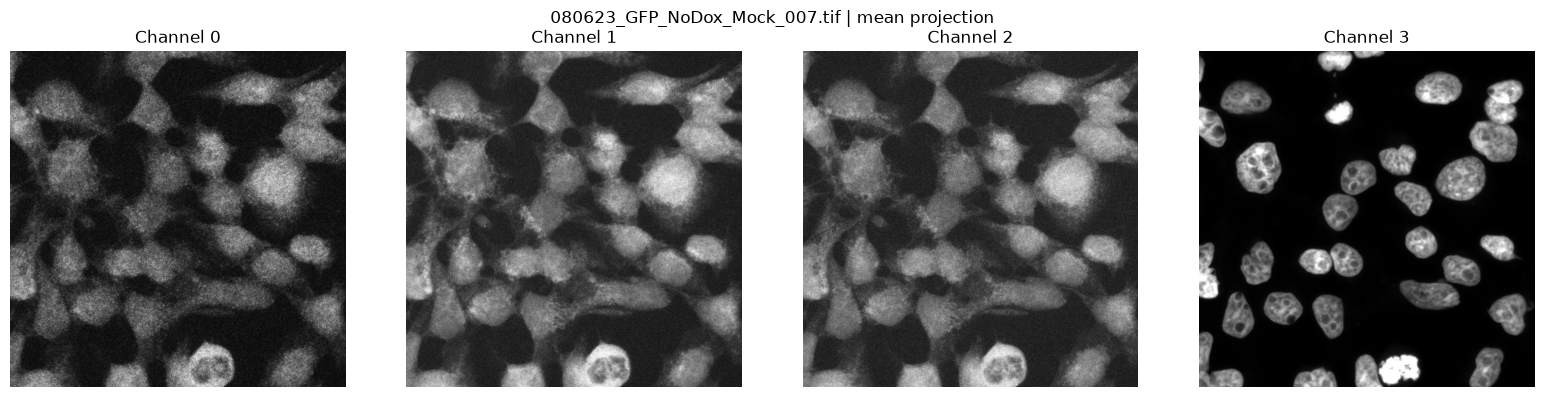

In [11]:
TEST_INDEX = 101  # choose from the file list above
INPUT_AXES = "ZCYX"
Z_PROJECTION = "mean"  # "max", "mean" or "sum"

test_path = files[TEST_INDEX]
with tifffile.TiffFile(test_path) as tif:
    print(f"{test_path.name}: shape={tif.series[0].shape}, TIFF axes={tif.series[0].axes}")
all_channels = load_projection(test_path, INPUT_AXES, Z_PROJECTION)

n_channels = all_channels.shape[-1]
columns = min(4, n_channels)
rows = (n_channels + columns - 1) // columns
fig, axs = plt.subplots(rows, columns, figsize=(4 * columns, 4 * rows), squeeze=False)
for i, ax in enumerate(axs.flat):
    if i < n_channels:
        channel = all_channels[..., i]
        lo, hi = np.percentile(channel, [1, 99])
        ax.imshow(channel, cmap="gray", vmin=lo, vmax=max(hi, lo + 1e-6))
        ax.set_title(f"Channel {i}")
    ax.axis("off")
fig.suptitle(f"{test_path.name} | {Z_PROJECTION} projection")
plt.tight_layout()
plt.show()

## Preview · edit and rerun this cell
Choose channels and adjust the settings below, then rerun this cell with **Ctrl+Enter**. The image and model stay loaded. Change one setting at a time and compare outlines on the same image before batching.

Input selection and smoothing (applied to the model input only; saved masks are unaffected):

- **`CHANNEL_INDICES`** (default `[3]`): zero-based channels from the panels above. Select 1–3 useful stains. With a nuclear stain alone the model returns nuclei; adding a cytoplasm/membrane channel makes it return whole cells. This is array selection, not the deprecated Cellpose `channels` argument.
- **`MEDIAN`** (default `None`): window size in pixels for a per-channel median filter, e.g. `5`. Removes speckle while preserving edges. The old notebook used `20` on 325 px cells, about 6% of the object diameter; scale accordingly.
- **`GAUSSIAN`** (default `None`): sigma in pixels for a per-channel Gaussian blur, e.g. `1.5`. Softens thin dark lines more than a median does. When both are set the median runs first.

`EVAL_SETTINGS` passed to `model.eval`:

- **`channel_axis`** (default `-1`): channels occupy the last axis of the prepared YXC image. Leave this unchanged with this loader.
- **`diameter`** (default `None`): use native scale; no automatic diameter estimation. A positive value (e.g. `325` for the old dataset) rescales so objects become 30 px, which also suppresses thin internal features such as nuclear folds and reduces over-segmentation; inspect whether small cells lose detail after downsampling.
- **`normalize`** (default `True`): normalize each channel using its 1st–99th intensity percentiles. Keep this on for raw images; use `False` only if you intentionally prepared the input intensities yourself. Panel autocontrast affects display only.
- **`flow_threshold`** (default `0.4`): reject masks with inconsistent flows. Raise it (e.g. `0.6`) to retain more candidate masks; lower it (e.g. `0.2`) to reject more poorly shaped masks. Higher is more permissive. This does not merge split objects.
- **`cellprob_threshold`** (default `0.0`): pixel inclusion cutoff. Lower it (e.g. `-1`) to include dimmer regions and often larger/more masks; raise it (e.g. `1`) to suppress background and often shrink/reduce masks. Check both missed cells and false positives.
- **`min_size`** (default `15`): discard masks smaller than this many pixels. Increase to remove tiny specks; decrease to retain small objects. It is an area cutoff, not a diameter.
- **`batch_size`** (default `1`): image tiles processed together. Increase cautiously for throughput if GPU memory allows. This does not set the number of image files.
- **`do_3D`** (default `False`): keep this off because the loader already projects Z. True 3D segmentation needs a different input workflow, not just this switch.

Optional additions to `EVAL_SETTINGS`:

- **`niter=None`** leaves dynamics iterations automatic. Try a larger value such as `2000` for long objects whose masks fail to converge; this takes longer.
- **`bsize=None`** uses each model's default tile size: 256 for SAM, 384 for DINO. DINO permits larger tiles for large/long objects at increased memory cost; SAM requires 256.

The standard Cellpose plot shows the smoothed model input, outlines, masks and flows. Display channels map to R/G/B in selected order. Guidance: [settings](https://cellpose.readthedocs.io/en/latest/settings.html), [API](https://cellpose.readthedocs.io/en/latest/api.html), [models](https://cellpose.readthedocs.io/en/latest/models.html).

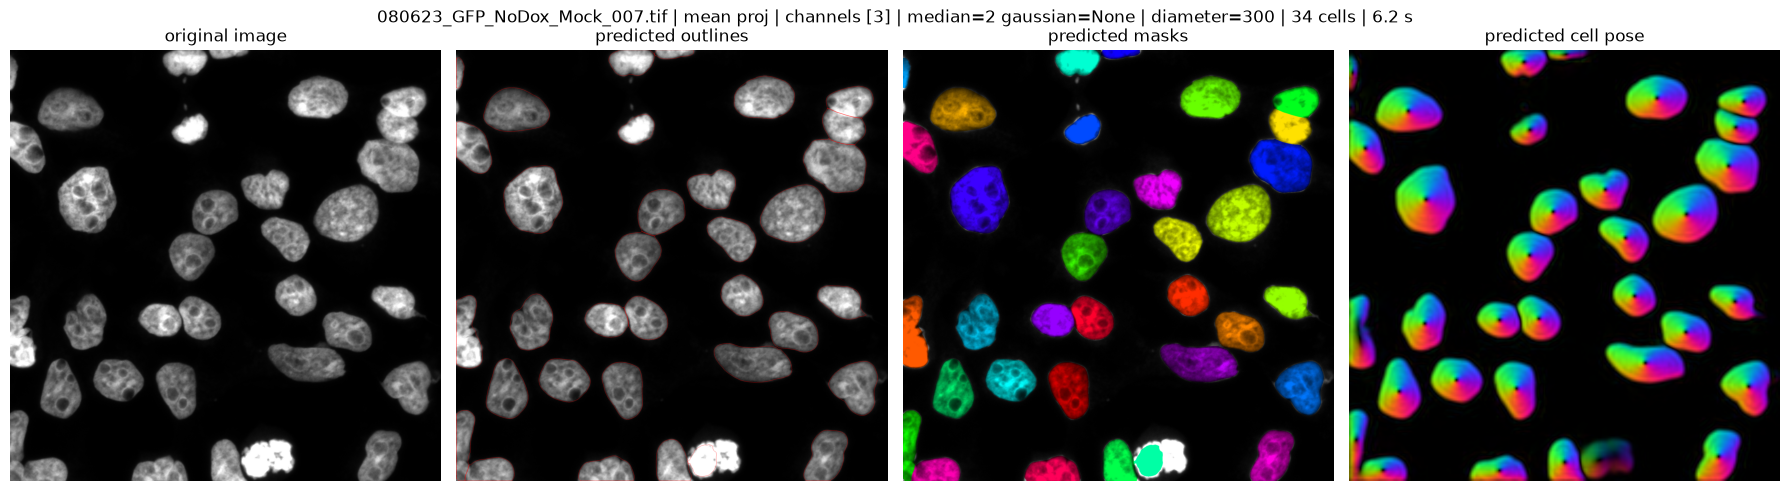

In [12]:
# EDIT THESE SETTINGS, THEN RERUN ONLY THIS CELL (Ctrl+Enter in VS Code).
CHANNEL_INDICES = [3]  # zero-based: up to three; [1] matches the old notebook
MEDIAN = 2          # None or window size in px, e.g. 5
GAUSSIAN = None        # None or sigma in px, e.g. 1.5
EVAL_SETTINGS = dict(
    channel_axis = -1,
    diameter = 300,
    normalize = True,
    flow_threshold = 0.4,
    cellprob_threshold = 0,
    min_size = 15,
    batch_size = 1,
    do_3D = False,
)


def qc_figure(image, masks, flows, name, seconds):
    """Standard Cellpose QC plot of the smoothed model input, outlines, masks and flows."""
    # Display-only per-channel autocontrast; model input stays unchanged.
    lo, hi = np.percentile(image, [1, 99], axis=(0, 1), keepdims=True)
    shown = np.clip((image - lo) / np.maximum(hi - lo, 1e-6), 0, 1)
    rgb = np.zeros((*image.shape[:2], 3), dtype=np.float32)
    if image.shape[-1] == 1:
        rgb[:] = shown
    else:
        rgb[..., :image.shape[-1]] = shown
    fig = plt.figure(figsize=(18, 5))
    plot.show_segmentation(fig, (rgb * 255).astype(np.uint8), masks, flows[0])
    fig.suptitle(f"{name} | {Z_PROJECTION} proj | channels {CHANNEL_INDICES} | "
                 f"median={MEDIAN} gaussian={GAUSSIAN} | diameter={EVAL_SETTINGS['diameter']} | "
                 f"{int(masks.max())} cells | {seconds:.1f} s")
    fig.tight_layout()
    return fig


assert 1 <= len(CHANNEL_INDICES) <= 3, "Select 1–3 channels."
assert all(0 <= c < all_channels.shape[-1] for c in CHANNEL_INDICES), "Invalid channel index."
image = preprocess(all_channels[..., CHANNEL_INDICES], MEDIAN, GAUSSIAN)
started = perf_counter()
masks, flows, _ = model.eval(image, **EVAL_SETTINGS)
qc_figure(image, masks, flows, test_path.name, perf_counter() - started)
plt.show()

## Batch · run after you are happy with the preview
Uses the current `Z_PROJECTION`, `CHANNEL_INDICES`, `MEDIAN`, `GAUSSIAN` and `EVAL_SETTINGS` from the cells above. After changing the folder or axes, rerun image loading and preview before batching. All files must share the same axis layout.

Writes a uint32 label TIFF `{base}_nucllabel.tif` (background = 0) and a QC figure `{base}_nucllabel-qc.png` (same plot as the preview) per image into `cellpose_sam_results`. Images listed in `EXCLUDED` (the "Excluded images" in `AGENTS.md`) are skipped. Existing outputs are skipped unless `OVERWRITE=True`. Errors stop the loop so you can inspect them; rerunning skips completed files.

In [ ]:
OUTPUT_DIR = Path("/Volumes/Jeff-exFAT/Marko_HIV/Marko_HIV_cpnuclmask")
OVERWRITE = False
# Shape differs from the rest of the dataset; see "Excluded images" in AGENTS.md.
EXCLUDED = {
    "160323_GFP_Dox_INF-48hpi_010.tif",
    "160323_MARF1_NoDox_INF-48hpi_006.tif",
}
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for path in tqdm(files, desc="Segmenting"):
    if path.name in EXCLUDED:
        print(f"Skipping excluded image: {path.name}")
        continue
    output = OUTPUT_DIR / f"{path.stem}__cpnuclmask.tif"
    qc_output = OUTPUT_DIR / f"{path.stem}__cpnuclmask-qc.png"
    if output.exists() and qc_output.exists() and not OVERWRITE:
        continue
    projected = all_channels if path == test_path else load_projection(path, INPUT_AXES, Z_PROJECTION)
    prepared = preprocess(projected[..., CHANNEL_INDICES], MEDIAN, GAUSSIAN)
    started = perf_counter()
    labels, batch_flows, _ = model.eval(prepared, **EVAL_SETTINGS)
    tifffile.imwrite(output, labels.astype(np.uint32),
                     photometric="minisblack", metadata={"axes": "YX"})
    fig = qc_figure(prepared, labels, batch_flows, path.name, perf_counter() - started)
    fig.savefig(qc_output, dpi=150)
    plt.close(fig)

print(f"Masks and QC figures saved to {OUTPUT_DIR}")

Segmenting:  61%|██████    | 357/585 [1:06:39<47:56, 12.62s/it]

Skipping excluded image: 160323_GFP_Dox_INF-48hpi_010.tif


Segmenting:  70%|███████   | 412/585 [1:17:45<40:05, 13.91s/it]

Skipping excluded image: 160323_MARF1_NoDox_INF-48hpi_006.tif


Segmenting: 100%|██████████| 585/585 [1:49:39<00:00, 11.25s/it]

Masks and QC figures saved to /Volumes/Jeff-exFAT/Marko_HIV_cpnuclmask


References: [Cellpose settings](https://cellpose.readthedocs.io/en/latest/settings.html), [API](https://cellpose.readthedocs.io/en/latest/api.html), [Apple Silicon installation](https://cellpose.readthedocs.io/en/latest/installation.html). Written against Cellpose 4.2.1.1; `eval` returns `(masks, flows, styles)` and the deprecated `channels` / `model_type` arguments are omitted.